In [2]:
pip install sdv sdmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 7.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import random

In [3]:
import sdv
import sdmetrics

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [4]:
from sdmetrics.reports.single_table import QualityReport

In [5]:
print("SDV: ", sdv.__version__)

SDV:  1.37.0


In [9]:
dfClientes = pd.DataFrame({
    "cliente_id": [1,2,3,4,5,6,7,8,9,10],
    "edad": [23,33,43,53,56,43,56,65,40,30], # Added '30' to make length 10
    "ingreso_mensual": [10000,20000,30000,40000,50000,60000,70000,80000,90000,100000],
    "ciudad": ["New York", "Los Angeles", "Chicago", "Houston", "Phoenix", "Philadelphia", "San Antonio", "San Diego", "Dallas", "San Jose"],
})

In [10]:
dfClientes.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,1,23,10000,New York
1,2,33,20000,Los Angeles
2,3,43,30000,Chicago
3,4,53,40000,Houston
4,5,56,50000,Phoenix


In [11]:
metadata = SingleTableMetadata()

In [12]:
metadata.detect_from_dataframe(data=dfClientes)

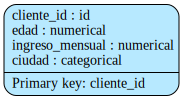

In [13]:
metadata.visualize()

In [14]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'primary_key': 'cliente_id'}

In [15]:
#Guardar metadata en un archivo json
metadata.save_to_json("dfClientes_metadata.json")

In [16]:
#Entrenamos el modelo para generar los datos sinteticos
synthesizer = GaussianCopulaSynthesizer(metadata)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [17]:
#Entrenamiendo
synthesizer.fit(
    dfClientes
)

In [18]:
clientes_sinteticos = synthesizer.sample(num_rows=100)

In [19]:
clientes_sinteticos.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,55,75368,San Diego
1,4918803,30,79129,Houston
2,1900081,39,51178,Houston
3,531516,31,54050,Chicago
4,10211768,37,86380,San Diego


In [20]:
clientes_sinteticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       100 non-null    int64 
 1   edad             100 non-null    int64 
 2   ingreso_mensual  100 non-null    int64 
 3   ciudad           100 non-null    object
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


In [21]:
clientes_sinteticos.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.000000e+02,100.000000,100.000000,100
unique,NaN,NaN,NaN,10
top,NaN,NaN,NaN,New York
freq,NaN,NaN,NaN,27
mean,8.532170e+06,39.780000,59511.180000,NaN
std,4.687773e+06,10.239141,26272.931476,NaN
min,4.660500e+04,30.000000,11186.000000,NaN
25%,5.008268e+06,31.000000,37095.750000,NaN
50%,8.656048e+06,35.000000,64411.500000,NaN
75%,1.256688e+07,47.000000,82671.750000,NaN


In [22]:
#DataFrame contaminado
dfClientesGIGO = clientes_sinteticos.copy()

In [24]:
#Colocar edades imposibles
indices = random.sample(list(dfClientesGIGO.index),5)


In [25]:
dfClientesGIGO.loc[indices, "edad"] = -5

In [26]:
#Introucimos valores duplicados
duplicados = dfClientesGIGO.sample(10,random_state=42)

In [27]:
dfClientesGIGO = pd.concat([dfClientesGIGO,duplicados], ignore_index=True)

In [28]:
#Verificamos valores nulos
dfClientesGIGO.duplicated().sum()

np.int64(10)

In [29]:
dfClientesGIGO.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.100000e+02,110.000000,110.000000,110
unique,NaN,NaN,NaN,10
top,NaN,NaN,NaN,New York
freq,NaN,NaN,NaN,33
mean,8.614045e+06,37.272727,57567.700000,NaN
std,4.775996e+06,13.500193,26907.537285,NaN
min,4.660500e+04,-5.000000,11186.000000,NaN
25%,4.948624e+06,31.000000,34794.500000,NaN
50%,8.956428e+06,34.000000,59199.000000,NaN
75%,1.274153e+07,46.750000,81891.500000,NaN


In [30]:
#Generamos reporte
reporte = QualityReport()

In [32]:
reporte.generate(
    real_data=dfClientes,
    synthetic_data= clientes_sinteticos,
    metadata=metadata.to_dict()
)


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 372.67it/s]|
Column Shapes Score: 80.33%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 115.18it/s]|
Column Pair Trends Score: 16.5%

Overall Score (Average): 48.42%



In [33]:
reporte.generate(
    real_data=dfClientes,
    synthetic_data= dfClientesGIGO,
    metadata=metadata.to_dict()
)


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 493.55it/s]|
Column Shapes Score: 78.18%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 190.65it/s]|
Column Pair Trends Score: 13.18%

Overall Score (Average): 45.68%

